In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [49]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [50]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/train",
    transform=train_transforms
)

val_dataset = ImageFolder(
    root="/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/val",
    transform=val_transforms
)

In [51]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # resize images
    transforms.ToTensor()            # convert to tensor
])

In [52]:
train_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/val",
    transform=transform
)

In [53]:
num_classes = len(train_dataset.classes)
print(num_classes)

38


In [54]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [55]:
from collections import Counter
import torch
import torch.nn as nn

targets = train_dataset.targets
class_counts = Counter(targets)

total_samples = len(targets)
num_classes = len(class_counts)

class_weights = [
    total_samples / class_counts[i]
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

In [56]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1),  # 224x224 -> 224x224
            nn.ReLU(),
            nn.MaxPool2d(2,2),          # 224 -> 112
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),          # 112 -> 56
            nn.Conv2d(64, 128, 3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)           # 56 -> 28
        )

        # Dynamically compute flatten size
        dummy_input = torch.zeros(1,3,224,224)
        with torch.no_grad():
            n_features = self.features(dummy_input).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate model
cnn_model = SimpleCNN(num_classes).to(device)
print(cnn_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=38, bias=True)
  )
)


In [57]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_dataset.classes)

In [58]:
cnn_model = SimpleCNN(num_classes).to(device)

In [59]:
cnn_model.load_state_dict(
    torch.load("/content/drive/MyDrive/best_model.pth", map_location=device)
)

cnn_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [60]:
classes = train_dataset.classes
print(classes)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [61]:
image_path = "/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/val/Apple___Apple_scab/0a14783a-838a-4d4f-a671-ff98011714c6___FREC_Scab 3288.JPG"

In [62]:
from PIL import Image

img = Image.open(image_path).convert("RGB")

In [63]:
img_tensor = transform(img).unsqueeze(0).to(device)

In [64]:
with torch.no_grad():
    outputs = cnn_model(img_tensor)
    _, predicted = torch.max(outputs, 1)

predicted_class = classes[predicted.item()]
print("Predicted class:", predicted_class)

Predicted class: Cherry_(including_sour)___healthy


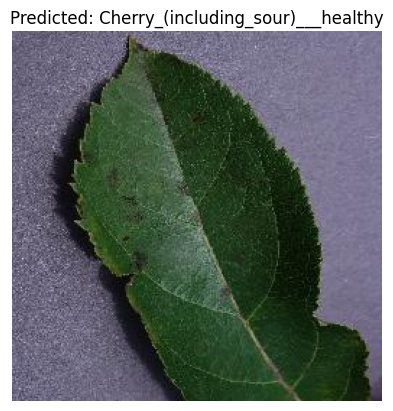

In [65]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()

In [66]:
import torch.nn.functional as F

probabilities = F.softmax(outputs, dim=1)
confidence = probabilities[0][predicted.item()].item() * 100

print(f"Confidence: {confidence:.2f}%")

Confidence: 21.74%


In [67]:
for i in range(5):
    image_path = val_dataset.samples[i][0]

    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = cnn_model(img_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    print("Pred:", classes[pred.item()])
    print("Confidence:", round(conf.item()*100,2), "%\n")

Pred: Cherry_(including_sour)___Powdery_mildew
Confidence: 95.07 %

Pred: Apple___healthy
Confidence: 36.19 %

Pred: Apple___healthy
Confidence: 52.11 %

Pred: Cherry_(including_sour)___healthy
Confidence: 21.74 %

Pred: Peach___healthy
Confidence: 33.28 %

